# 3. Transfer Learning — Bootstrap Model

Train the **first** object detection model using transfer learning on the small,
balanced bootstrap dataset (63 images). The result is a baseline model fully
tracked in MLflow.

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Device Configuration](#2-device-configuration)
3. [Dataset Verification](#3-dataset-verification)
4. [Data Configuration](#4-data-configuration)
5. [Model & Hyperparameters](#5-model--hyperparameters)
6. [Training](#6-training)
7. [Evaluation](#7-evaluation)
8. [MLflow Logging](#8-mlflow-logging)
9. [Results Summary](#9-results-summary)

## 1. Setup & Imports

In [ ]:
%matplotlib inline
import torch
import mlflow
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

from utils.config import (
    PREPROCESSED_DIR, BOOTSTRAP_DIR, TEST_DIR,
    CLASS_NAMES, NUM_CLASSES, SEED,
    PRETRAINED_WEIGHTS, RUNS_DIR, MLFLOW_MODEL_NAME,
)
from utils.mlflow_helpers import (
    setup_mlflow,
    log_yolo_run_artifacts, log_yolo_epoch_metrics, register_yolo_model,
)
from utils.training_helpers import (
    get_device, create_dataset_yaml,
    evaluate_model, visualize_predictions,
)

## 2. Device Configuration

In [2]:
device = get_device()

Device : GPU
  GPU  : NVIDIA GeForce MX230
  VRAM : 4.2 GB


## 3. Dataset Verification

Only the **bootstrap** dataset is used for this initial training.
The test set is fixed and used exclusively for evaluation.

In [3]:
bootstrap_imgs = list((BOOTSTRAP_DIR / "images").glob("*.jpg"))
bootstrap_lbls = list((BOOTSTRAP_DIR / "labels").glob("*.txt"))
test_imgs = list((TEST_DIR / "images").glob("*.jpg"))
test_lbls = list((TEST_DIR / "labels").glob("*.txt"))

print(f"Bootstrap : {len(bootstrap_imgs)} images, {len(bootstrap_lbls)} labels")
print(f"Test      : {len(test_imgs)} images, {len(test_lbls)} labels")

assert len(bootstrap_imgs) > 0, "Bootstrap dataset is empty!"
assert len(test_imgs) > 0, "Test dataset is empty!"

Bootstrap : 199 images, 199 labels
Test      : 893 images, 893 labels


## 4. Data Configuration

Generate (or reuse) the YOLO data YAML that points training to the
bootstrap subset and validation to the fixed test set.

In [4]:
yaml_path = create_dataset_yaml("bootstrap")
print(f"Data YAML: {yaml_path}")

YAML created: /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/bootstrap_data.yaml
Data YAML: /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/bootstrap_data.yaml


## 5. Model & Hyperparameters

Load YOLOv8-Nano with pretrained COCO weights and define training
hyperparameters compatible with ~4 GB VRAM.

In [5]:
# ── Hyperparameters ──
MODEL_VARIANT = "yolov8n"
DATASET_ID    = "bootstrap"
EPOCHS        = 25
BATCH_SIZE    = 8
IMG_SIZE      = 640
LR            = 0.01

# ── Load pretrained model ──
model = YOLO(str(PRETRAINED_WEIGHTS))
print(f"Model   : {MODEL_VARIANT}")
print(f"Weights : {PRETRAINED_WEIGHTS.name}")

Model   : yolov8n
Weights : yolov8n.pt


## 6. Training

Run transfer learning on the bootstrap dataset. Training is short
and controlled — no hyperparameter search.

In [6]:
results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    lr0=LR,
    device=device,
    seed=SEED,
    project=str(RUNS_DIR),
    name=f"{DATASET_ID}_training",
    exist_ok=True,
    verbose=True,
)

# Path to the best checkpoint
best_pt = Path(model.trainer.save_dir) / "weights" / "best.pt"
print(f"\nBest model saved at: {best_pt}")

New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.196 🚀 Python-3.10.14 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce MX230, 4034MiB)
WARNING ⚠️ Upgrade to torch>=2.0.0 for deterministic training.
engine/trainer: task=detect, mode=train, model=/home/paul/universidad/septimo/IA/final_proyect/notebooks/yolov8n.pt, data=/home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/bootstrap_data.yaml, epochs=25, patience=50, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/home/paul/universidad/septimo/IA/final_proyect/notebooks/runs, name=bootstrap_training, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=Fal


Best model saved at: /home/paul/universidad/septimo/IA/final_proyect/notebooks/runs/bootstrap_training/weights/best.pt


## 7. Evaluation

Evaluate the best checkpoint on the **fixed** test set.
Metrics: mAP@0.5, mAP@0.5:0.95, precision, recall, F1.

In [7]:
best_model = YOLO(str(best_pt))
metrics = evaluate_model(best_model, data_yaml=yaml_path, img_size=IMG_SIZE)

print("\n── Quality Metrics (test set) ──")
for k, v in metrics.items():
    print(f"  {k:12s}: {v:.4f}")

Ultralytics YOLOv8.0.196 🚀 Python-3.10.14 torch-1.13.1+cu117 CUDA:0 (NVIDIA GeForce MX230, 4034MiB)
Model summary (fused): 168 layers, 3006428 parameters, 0 gradients, 8.1 GFLOPs
val: Scanning /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/test/labels.cache... 893 images, 0 backgrounds, 0 corrupt: 100%|██████████| 893/893 [00:00<?, ?
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:26<00:00,  2.10it/s]
                   all        893       1558      0.532      0.457      0.485      0.319
Speed: 1.0ms preprocess, 22.7ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /home/paul/.pyenv/runs/detect/val11



── Quality Metrics (test set) ──
  mAP50       : 0.4847
  mAP50-95    : 0.3187
  precision   : 0.5318
  recall      : 0.4569
  f1          : 0.4915


## 8. MLflow Logging

Log hyperparameters, metrics, and the model artifact to MLflow.

In [ ]:
experiment = setup_mlflow()

with mlflow.start_run(run_name="bootstrap_transfer_learning") as run:
    mlflow.log_params({
        "model_variant": MODEL_VARIANT,
        "pretrained_weights": PRETRAINED_WEIGHTS.name,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "img_size": IMG_SIZE,
        "learning_rate": LR,
        "dataset": DATASET_ID,
        "num_classes": NUM_CLASSES,
        "seed": SEED,
    })

    # Metrics
    mlflow.log_metrics(metrics)

    mlflow.log_artifact(str(best_pt), artifact_path="model")

    yolo_save_dir = Path(model.trainer.save_dir)
    log_yolo_run_artifacts(yolo_save_dir)

    log_yolo_epoch_metrics(yolo_save_dir)

    register_yolo_model(best_pt, MLFLOW_MODEL_NAME)

    run_id = run.info.run_id

print(f"\nMLflow Run ID : {run_id}")
print(f"Run Name      : bootstrap_transfer_learning")

## 9. Results Summary

Visual overview of baseline model predictions on the test set.

In [9]:
# Summary table
summary = pd.DataFrame({
    "Parameter": ["Model", "Dataset", "Epochs", "Batch Size",
                  "Image Size", "Learning Rate", "MLflow Run ID"],
    "Value": [MODEL_VARIANT, DATASET_ID, EPOCHS, BATCH_SIZE,
              IMG_SIZE, LR, run_id],
})
display(summary)

metrics_df = pd.DataFrame(metrics, index=["bootstrap"]).T
metrics_df.columns = ["Value"]
display(metrics_df)

,Parameter,Value
0,Model,yolov8n
1,Dataset,bootstrap
2,Epochs,25
3,Batch Size,8
4,Image Size,640
5,Learning Rate,0.01
6,MLflow Run ID,228014a921414f9d944c114c03dfae3e


,Value
mAP50,0.4847
mAP50-95,0.3187
precision,0.5318
recall,0.4569
f1,0.4915


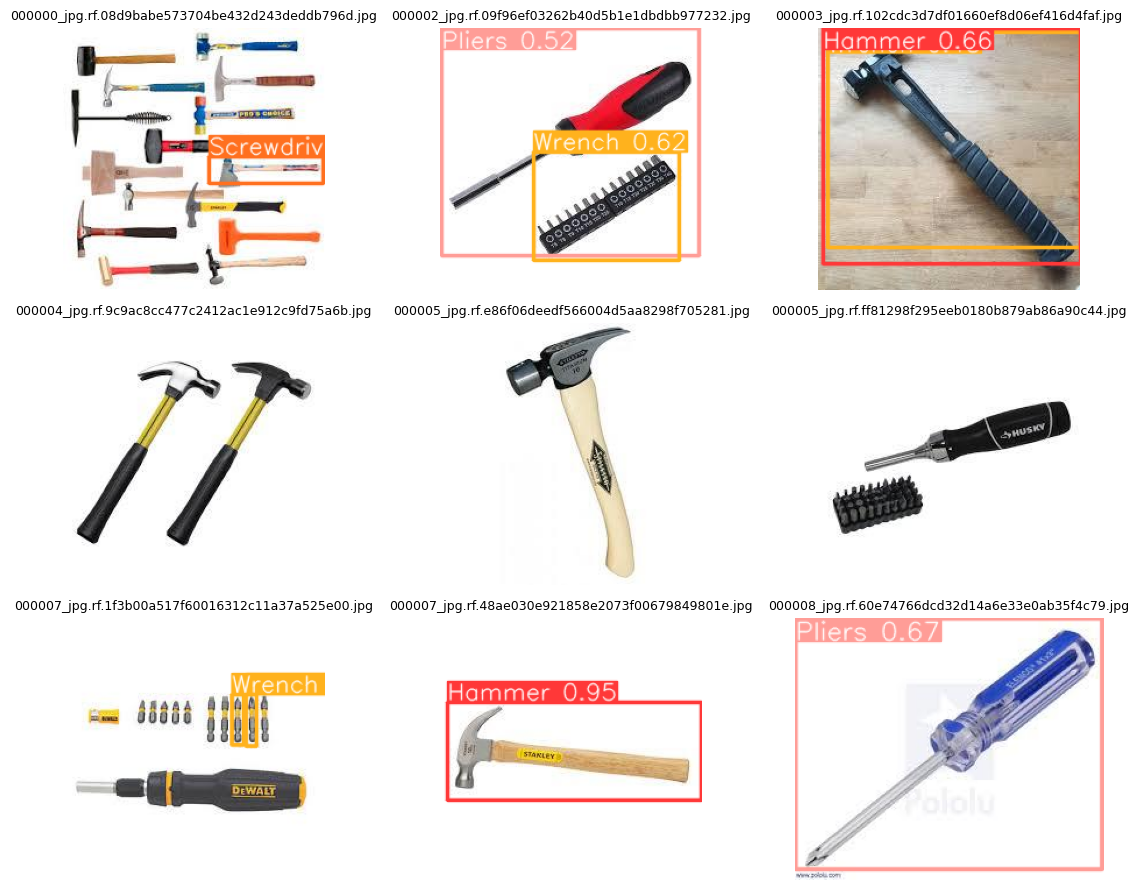

In [12]:
visualize_predictions(best_model, TEST_DIR / "images", num_images=9, conf=0.40)